In [1]:
import numpy as np
from aeon.classification import BaseClassifier
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from aeon.transformations.collection.interval_based import QUANTTransformer
import numpy as np
import polars as pl
from aeon.classification.base import BaseClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
import os
from aeon.transformations.collection.convolution_based import Rocket
from aeon.datasets.tsc_datasets import univariate
from sklearn.base import clone
from aeon.classification.convolution_based import MultiRocketHydraClassifier
from aeon.classification.convolution_based import RocketClassifier
from sklearn.metrics import accuracy_score
from aeon.classification.interval_based import QUANTClassifier
from autotsc import utils, models
from tqdm import tqdm
from aeon.classification.feature_based import Catch22Classifier
from aeon.transformations.collection import DownsampleTransformer
from aeon.classification.distance_based import ProximityForest
from aeon.classification.interval_based import QUANTClassifier
from aeon.classification.shapelet_based import RDSTClassifier

2025-12-04 14:58:52.420639: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import numpy as np
from scipy.interpolate import interp1d
from aeon.transformations.collection.base import BaseCollectionTransformer


class DownsampleTransformer(BaseCollectionTransformer):
    _tags = {
        "X_inner_type": ["np-list", "numpy3D"],
        "capability:multivariate": True,
        "capability:unequal_length": True,
        "fit_is_empty": True,
    }

    def __init__(self, proportion):
        self.proportion = proportion
        super().__init__()

    def _transform(self, X, y=None):
        self._check_parameters()

        is_np = isinstance(X, np.ndarray)
        out = []

        for x in X:
            c, t = x.shape
            new_t = max(2, int(round(t * self.proportion)))

            old_grid = np.linspace(0, 1, t)
            new_grid = np.linspace(0, 1, new_t)

            xr = np.zeros((c, new_t))
            for i in range(c):
                f = interp1d(old_grid, x[i], kind="linear")
                xr[i] = f(new_grid)

            out.append(xr)

        return np.asarray(out) if is_np else out

    def _check_parameters(self):
        if not (0 < self.proportion < 1):
            raise ValueError("proportion must be between 0 and 1")


In [3]:
write_dir = "experiments/automl_downsampling"
os.makedirs(write_dir, exist_ok=True)

In [4]:
def get_model(name, random_state=None):
    if name == "hydra-mr":
        return MultiRocketHydraClassifier(random_state=random_state, n_jobs=-1)
    elif name == 'pf':
        return ProximityForest(random_state=random_state, n_jobs=-1)
    elif name == 'quant':
        return QUANTClassifier(random_state=random_state)
    elif name == 'rdst':
        return RDSTClassifier(random_state=random_state, n_jobs=-1)
    else:
        raise ValueError(f"Unknown model name: {name}")

In [5]:
for dataset in univariate:
    for model_name in ['hydra-mr', 'quant', 'rdst']:
        for run in range(1):
            for downsample_rate in [None, 1.0, 0.9, 0.7, 0.5, 0.3, 0.2, 0.1]:
                try: 
                    stats = {
                        "dataset": dataset,
                        "model": model_name,
                        "run": run,
                        "downsample_rate": downsample_rate,
                    }

                    hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
                    file = f"{write_dir}/{hash_val}.parquet"

                    if os.path.exists(file):
                        print(f"Skipping: Dataset={dataset}, Run={run}, Model={model_name}")
                        continue
                    else:
                        print(f"Processing: Dataset={dataset}, Run={run}, Model={model_name}, Downsample rate={downsample_rate}")

                    #print(f"Dataset: {dataset}, Model: {model_name}, Run: {run}, Downsample rate: {downsample_rate}")
                    model = get_model(model_name)
                    X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
                    if downsample_rate is None or downsample_rate >= 1.0:
                        X_train_ds = X_train
                        X_test_ds = X_test
                    else:
                        ds = DownsampleTransformer(proportion=downsample_rate)
                        X_train_ds = ds.fit_transform(X_train)
                        X_test_ds = ds.transform(X_test)
                    print(f"Downsampled by {downsample_rate}: {X_train.shape} -> {X_train_ds.shape}")
                    model.fit(X_train_ds, y_train)
                    pred = model.predict(X_test_ds)
                    acc = accuracy_score(y_test, pred)

                    stats["test_accuracy"] = acc

                    df_stat = pl.DataFrame([stats])
                    df_stat.write_parquet(file, mkdir=True)
                except Exception as e:
                    print(e)


Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=hydra-mr
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=rdst
Skipping: Dataset=ACSF1, Run=0, Model=rdst
Skipping: Dataset=ACSF1, Run=0, Model=rdst
Skipping: Dataset=ACSF1, Run=0, Model=rdst
Skipping: Dataset=ACSF1, Run=0, Model=rdst
Skipping: Dataset=ACSF1, Run=0, Model=rdst
Skipping: Data

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/aeon/transformations/collection/interval_based/_quant.py:134: RuntimeWarning: divide by zero encountered in log2
  exponent = min(self.interval_depth, int(np.log2(input_length)) + 1)


Downsampled by 0.2: (7200, 1, 46) -> (7200, 1, 9)
unable to broadcast argument 1 to output array
File "/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/aeon/transformations/collection/convolution_based/_multirocket.py", line 1, 
Processing: Dataset=Crop, Run=0, Model=hydra-mr, Downsample rate=0.1
Downsampled by 0.1: (7200, 1, 46) -> (7200, 1, 5)
torch.cat(): expected a non-empty list of Tensors
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=quant
Skipping: Dataset=Crop, Run=0, Model=rdst
Skipping: Dataset=Crop, Run=0, Model=rdst
Skipping: Dataset=Crop, Run=0, Model=rdst
Skipping: Dataset=Crop, Run=0, Model=rdst
Skipping: Dataset=Crop, Run=0, Model=rdst
Skipping: Dataset=Crop,

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/aeon/transformations/collection/interval_based/_quant.py:134: RuntimeWarning: divide by zero encountered in log2
  exponent = min(self.interval_depth, int(np.log2(input_length)) + 1)


Downsampled by 0.3: (1138, 1, 24) -> (1138, 1, 7)
n_timepoints must be >= 9, but found 7; zero pad shorter series so that n_timepoints == 9
Processing: Dataset=MelbournePedestrian, Run=0, Model=hydra-mr, Downsample rate=0.2
Downsampled by 0.2: (1138, 1, 24) -> (1138, 1, 5)
torch.cat(): expected a non-empty list of Tensors
Processing: Dataset=MelbournePedestrian, Run=0, Model=hydra-mr, Downsample rate=0.1
Downsampled by 0.1: (1138, 1, 24) -> (1138, 1, 2)
upper bound and lower bound inconsistent with step sign
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Skipping: Dataset=MelbournePedestrian, Run=0, Model=quant
Processing: Dataset=MelbournePedestrian, Run=0, Model=quant, Downsample rate=0.1

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/aeon/transformations/collection/interval_based/_quant.py:134: RuntimeWarning: divide by zero encountered in log2
  exponent = min(self.interval_depth, int(np.log2(input_length)) + 1)


Downsampled by 0.1: (600, 1, 80) -> (600, 1, 8)
n_timepoints must be >= 9, but found 8; zero pad shorter series so that n_timepoints == 9
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=quant
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=rdst
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=rdst
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=rdst
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=rdst
Skipping: Dataset=MiddlePhalanxOutlineCorrect, Run=0, Model=rdst
Skipping:

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/aeon/transformations/collection/interval_based/_quant.py:134: RuntimeWarning: divide by zero encountered in log2
  exponent = min(self.interval_depth, int(np.log2(input_length)) + 1)


Downsampled by 0.1: (27, 1, 65) -> (27, 1, 6)
n_timepoints must be >= 9, but found 6; zero pad shorter series so that n_timepoints == 9
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=quant
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=rdst
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=rdst
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=rdst
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=rdst
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=rdst
Skipping: Dataset=SonyAIBORobotSurface2, Run=0, Model=rdst
Skipping: Dataset=SonyAIBORobo

In [6]:
df = pl.read_parquet(write_dir + "/*.parquet").filter(pl.col("model") == "hydra-mr")
df

dataset,model,run,downsample_rate,test_accuracy
str,str,i64,f64,f64
"""UWaveGestureLibraryY""","""hydra-mr""",0,0.1,0.765215
"""ACSF1""","""hydra-mr""",0,0.1,0.81
"""Chinatown""","""hydra-mr""",1,0.5,0.976676
"""Fungi""","""hydra-mr""",0,0.1,0.758065
"""EthanolLevel""","""hydra-mr""",2,0.1,0.658
…,…,…,…,…
"""ShakeGestureWiimoteZ""","""hydra-mr""",0,0.7,0.92
"""ScreenType""","""hydra-mr""",0,1.0,0.530667
"""AllGestureWiimoteY""","""hydra-mr""",3,1.0,0.775714


<Axes: xlabel='downsample_rate', ylabel='test_accuracy'>

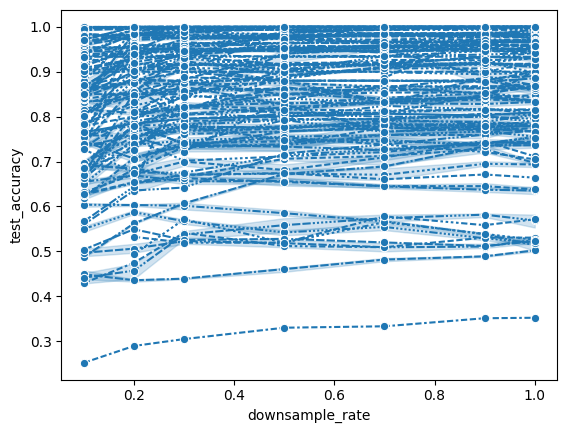

In [7]:
import seaborn as sns
sns.lineplot(data=df.to_pandas(), x='downsample_rate', y='test_accuracy', marker='o', style='dataset', legend=None)


In [8]:
df

dataset,model,run,downsample_rate,test_accuracy
str,str,i64,f64,f64
"""UWaveGestureLibraryY""","""hydra-mr""",0,0.1,0.765215
"""ACSF1""","""hydra-mr""",0,0.1,0.81
"""Chinatown""","""hydra-mr""",1,0.5,0.976676
"""Fungi""","""hydra-mr""",0,0.1,0.758065
"""EthanolLevel""","""hydra-mr""",2,0.1,0.658
…,…,…,…,…
"""ShakeGestureWiimoteZ""","""hydra-mr""",0,0.7,0.92
"""ScreenType""","""hydra-mr""",0,1.0,0.530667
"""AllGestureWiimoteY""","""hydra-mr""",3,1.0,0.775714


In [9]:
# pivot so each downsample_rate and each row is a dataset, values are test_accuracy
pdf = df.pivot(values='test_accuracy', index='dataset', on='downsample_rate', aggregate_function='mean')
dd_vals = df['downsample_rate'].unique().to_list()
pdf = pdf.drop_nulls()#.select(dd_vals)
pdf

dataset,0.1,0.5,0.9,0.2,0.7,0.3,1.0,null
str,f64,f64,f64,f64,f64,f64,f64,f64
"""UWaveGestureLibraryY""",0.765215,0.800949,0.802624,0.785036,0.806533,0.794807,0.809883,0.80737
"""ACSF1""",0.816,0.866,0.842,0.808,0.838,0.818,0.902,0.9
"""Fungi""",0.756989,1.0,1.0,0.982796,1.0,1.0,1.0,1.0
"""EthanolLevel""",0.6548,0.6568,0.6372,0.6692,0.6448,0.656,0.6356,0.636
"""FordB""",0.660741,0.83037,0.828148,0.809383,0.829877,0.823704,0.832593,0.828395
…,…,…,…,…,…,…,…,…
"""Plane""",0.971429,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""PLAID""",0.869646,0.934823,0.945996,0.891993,0.934823,0.912477,0.942272,0.944134
"""ToeSegmentation1""",0.912281,0.95614,0.960526,0.951754,0.951754,0.947368,0.95614,0.95614


In [10]:
h = pdf.select([str(x) for x in dd_vals])

ColumnNotFoundError: unable to find column "None"; valid columns: ["dataset", "0.1", "0.5", "0.9", "0.2", "0.7", "0.3", "1.0", "null"]

In [ ]:
from aeon.visualisation import plot_critical_difference
plot_critical_difference(h.to_numpy(), [str(x) for x in dd_vals])

In [ ]:
X_train, y_train, X_test, y_test = utils.load_dataset('FordA')
from time import perf_counter

time = []
accs = []
for downsample_rate in [0.99, 0.9, 0.7, 0.5, 0.3, 0.2, 0.1]:
    m = get_model('hydra-mr')

    ds = DownsampleTransformer(proportion=downsample_rate)
    X_train_ds = ds.fit_transform(X_train)
    X_test_ds = ds.transform(X_test)

    start = perf_counter()
    m.fit(X_train_ds, y_train)
    end = perf_counter()
    time.append(end - start)
    pred = m.predict(X_test_ds)
    acc = accuracy_score(y_test, pred)
    accs.append(acc)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(time, accs)

In [ ]:
plt.plot([0.99, 0.9, 0.7, 0.5, 0.3, 0.2, 0.1], time)

In [ ]:
df = pl.read_parquet(write_dir + "/*.parquet").sort('downsample_rate')
df

In [ ]:
v = df.filter(pl.col('downsample_rate').is_null()).pivot(values='test_accuracy', index='dataset', on='model', aggregate_function='mean').sort('dataset')
v

In [ ]:
models = df['model'].unique().to_list()
rates = df.filter(pl.col('downsample_rate').is_not_nan())['downsample_rate'].unique().to_list()

In [ ]:
stats = []
for downsample_rate in sorted(rates):
    v1 = df.filter(pl.col('downsample_rate') == downsample_rate).pivot(values='test_accuracy', index='dataset', on='model', aggregate_function='mean').sort('dataset')
    h = v1.join(v, on='dataset', suffix='-true').drop_nulls()

    for row in h.iter_rows(named=True):
        pass
        true_accs = [row[f"{model}-true"] for model in models]
        downsampled_accs = [row[model] for model in models]
        corr = np.corrcoef(true_accs, downsampled_accs)[0, 1]
        stats.append({
            "dataset": row['dataset'],
            "downsample_rate": downsample_rate,
            "correlation": corr,
        })

df = pl.DataFrame(stats)
df.drop_nans().group_by('downsample_rate').mean().sort('downsample_rate')

In [ ]:
df